In the world of statistics, the **Normal Distribution** (also known as the Gaussian distribution) is the "Gold Standard." It describes a data set where most observations cluster around a central peak, and the probabilities for values taper off equally in both directions.

If you’ve ever heard of a **"Bell Curve,"** you’re looking at a normal distribution.

---

## Key Characteristics

For a distribution to be truly "normal," it must check these boxes:

* **Symmetry:** The left half is a mirror image of the right half.
* **Central Tendency:** The **Mean** (average), **Median** (middle value), and **Mode** (most frequent value) are all exactly the same and located at the center of the curve.
* **The "Bell" Shape:** The curve is highest in the middle and flattens out toward the "tails" at the ends, but technically never touches the horizontal axis.

---

## The 68-95-99.7 Rule

One of the coolest things about a normal distribution is its predictability. Scientists use the **Standard Deviation** (a measure of how spread out the numbers are) to understand the data:

* **68%** of the data falls within **1 standard deviation** of the mean.
* **95%** of the data falls within **2 standard deviations** of the mean.
* **99.7%** of the data falls within **3 standard deviations** of the mean.
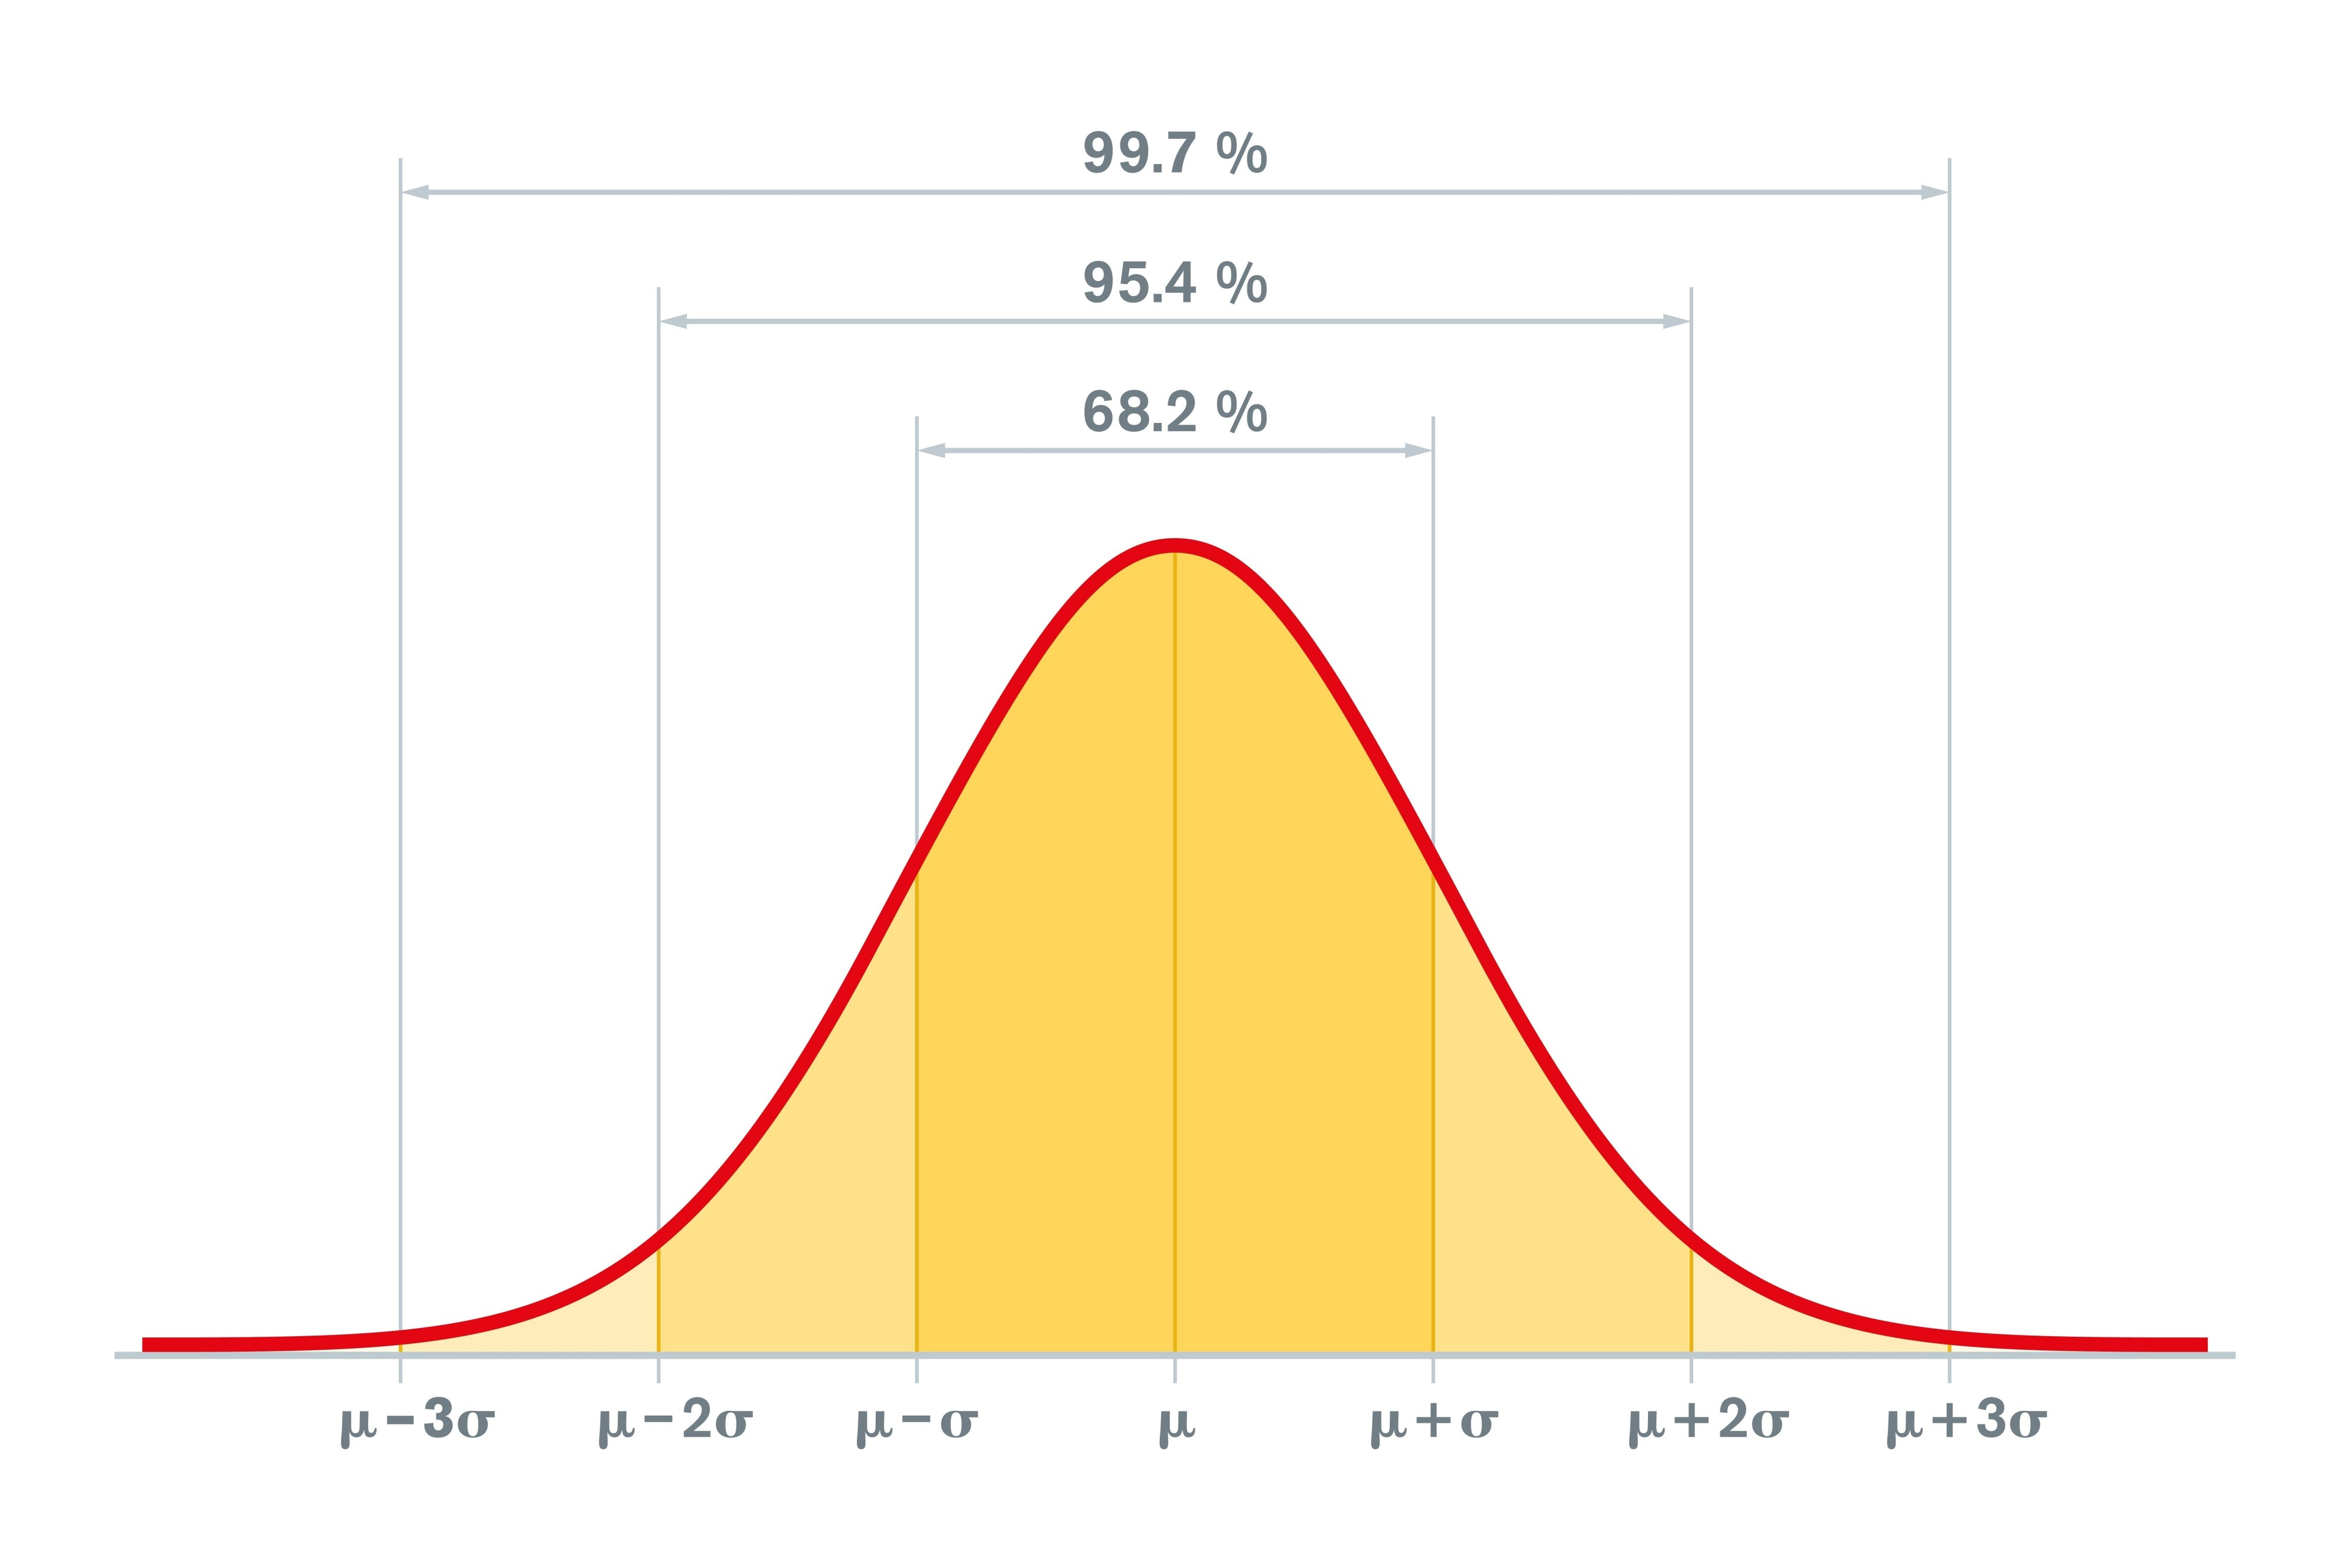
---

## Why does it matter?

The normal distribution occurs naturally in almost every field. Because it is so common, many statistical tests are designed specifically for it. You'll find it in:

1. **Biology:** Heights, weights, and blood pressure of a population.
2. **Education:** SAT or IQ scores.
3. **Finance:** Stock market returns (though they can be a bit "messier" in reality).
4. **Manufacturing:** Small variations in the size of a manufactured part.



To show you how this works in the real world, let’s use a classic example: **The height of adult men in a specific city.**

Imagine we measure 1,000 men and find that the **average (mean)** height is **175 cm**, with a **standard deviation of 7 cm**. Here is how that data would be represented on a normal distribution curve.

---

## 1. The Center (The Mean)

The very peak of the curve sits at **175 cm**.

* This tells us that the most common height is 175 cm.
* Because the curve is symmetrical, it also means 50% of the men are shorter than 175 cm and 50% are taller.

---

## 2. The Spread (Standard Deviations)

We use that 7 cm "ruler" (the standard deviation) to see how the rest of the population is distributed:

| Range | Calculation | Percentage of Population |
| --- | --- | --- |
| **Average Range** | $175 \pm 7$ cm | **68%** are between 168 cm and 182 cm |
| **Broad Range** | $175 \pm 14$ cm | **95%** are between 161 cm and 189 cm |
| **Extreme Range** | $175 \pm 21$ cm | **99.7%** are between 154 cm and 196 cm |

---

## 3. The "Outliers" (The Tails)

What about the people left over?

* Only **0.3%** of the population falls outside that 154 cm – 196 cm range.
* This means finding someone taller than 196 cm (6'5") or shorter than 154 cm (5'0") is statistically rare in this specific group.

---

## What this representation tells us:

By putting your data into this distribution, we can answer specific questions:

1. **Probability:** "What are the chances of meeting someone over 189 cm?" (Answer: About 2.5%).
2. **Comparison:** If you are 182 cm tall, you know you are taller than roughly 84% of the population.
3. **Consistency:** It tells us if the data is "behaving." If we found 200 men who were all 210 cm tall, we would know our data set is either biased or we are looking at a basketball team, not a "normal" population.



In Machine Learning, most models (like Linear Regression, Logistic Regression, and LDA) assume that your features follow a **Normal Distribution**. However, real-world data is often "messy"—it might be skewed, have outliers, or vary across different scales.

**Mathematical transformations** are used in feature engineering to reshape the data distribution, stabilize variance, and make the relationship between variables more linear.

---

## 1. Common Power Transformations

These are used to fix **skewness** (where data "bunches up" on one side).

### Log Transformation

* **Formula:** $y = \log(x)$
* **Best for:** Right-skewed data (positive skew).
* **Why use it:** it compresses high values and expands low values. It’s perfect for data with exponential growth or high variance, like income or population.
* **Constraint:** $x$ must be $> 0$.

### Square Root ($\sqrt{x}$) & Reciprocal ($1/x$)

* **Square Root:** A "medium-strength" transformation for right-skewed data. It’s less aggressive than the Log transform.
* **Reciprocal:** The most aggressive transformation. It "flips" the data; very small values become very large, and vice versa. It’s useful for ratios or when the "rate" of a variable is more important than the value itself.

### Square ($x^2$) & Power

* **Formula:** $y = x^n$
* **Best for:** Left-skewed data (negative skew).
* **Why use it:** It stretches the right side of the distribution, helping "pull" the tail toward the center.

---

## 2. Advanced Parametric Transformations

Instead of guessing which power to use, these methods use a parameter ($\lambda$) to find the best transformation automatically.

### Box-Cox Transformation

The Box-Cox attempts to find the exponent $\lambda$ that best transforms the data into a normal distribution.

* **The Math:** 
$$y(\lambda) = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(x) & \text{if } \lambda = 0 \end{cases}$$


* **Constraint:** Only works for **strictly positive data** ($x > 0$).

### Yeo-Johnson Transformation

This is the "modern" version of Box-Cox. It is more versatile because it handles **positive, zero, and negative values**.

* **Why use it:** It’s the "go-to" when you don't want to worry about zeros or negative numbers in your dataset while still aiming for normality.

---

## 3. Implementation: Function Transformers

In the Python library `Scikit-Learn`, these transformations are applied using the **`FunctionTransformer`**.

### Why use a Function Transformer?

If you just apply `np.log(df)`, it works for an ad-hoc analysis. But in a **Machine Learning Pipeline**, you need a transformer that:

1. Can be stored and reused.
2. Works with `Pipeline` objects for cross-validation.
3. Treats training and testing data identically.

**Example Code Snippet:**

```python
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Define the transformer
log_transformer = FunctionTransformer(np.log1p) # log1p handles log(x+1) to avoid zeros

# Apply to data
X_transformed = log_transformer.transform(X)

```

---

## Summary Comparison

| Transformation | Used For | Data Requirement |
| --- | --- | --- |
| **Log** | Strong Right Skew | $x > 0$ |
| **Sqrt** | Mild Right Skew | $x \ge 0$ |
| **Square** | Left Skew | Any |
| **Reciprocal** | Extreme Right Skew | $x \neq 0$ |
| **Box-Cox** | Finding optimal $\lambda$ | $x > 0$ |
| **Yeo-Johnson** | Finding optimal $\lambda$ | Any |

---



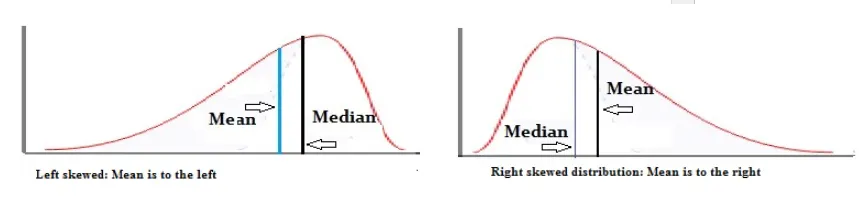